<a href="https://colab.research.google.com/github/Sadakbay/Crtr/blob/main/nkzbert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('nkzbert.csv')

In [ ]:
df = df.iloc[:, 1:]

In [ ]:
# Select relevant columns (CODE and job titles)
relevant_columns = ['CODE', 'NAME_RU', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

# Filter the dataframe to keep only relevant columns
df_cleaned = df[relevant_columns]

# Prepare a list to store transformed rows
transformed_rows = []

# Iterate over each row in the dataframe
for idx, row in df_cleaned.iterrows():
    code = row['CODE']  # Get the code value for the row
    job_titles = row[1:]  # Get job titles (excluding 'CODE')

    # Append each non-NaN job title with its corresponding code to the list
    for job_title in job_titles.dropna():
        transformed_rows.append([code, job_title])

# Convert the list of transformed rows into a dataframe
df_transformed = pd.DataFrame(transformed_rows, columns=['CODE', 'Job Title'])

# Display or save the result
print(df_transformed)

# Optionally, save to CSV

             CODE                                          Job Title
0      1111-1-001  ПРЕМЬЕР-МИНИСТР РЕСПУБЛИКИ КАЗАХСТАН, ЕГО ПЕРВ...
1      1111-1-001                                ГЛАВА ПРАВИТЕЛЬСТВА
2      1111-1-001                                            ПРЕМЬЕР
3      1111-1-001                                       ВИЦЕ-ПРЕМЬЕР
4      1111-1-002     ГОСУДАРСТВЕННЫЙ СЕКРЕТАРЬ РЕСПУБЛИКИ КАЗАХСТАН
...           ...                                                ...
52873  1111-1-032                 Директор статистического агентства
52874    1-99-999  Должность государственного служащего не опреде...
52875    1-99-999                           Государственный служащий
52876    1-99-999                  Сотрудник государственного органа
52877    1-99-999                                 Работник госслужбы

[52878 rows x 2 columns]


In [ ]:
import re

def clean_strings(text: str) -> str:
    # Replace dashes with spaces
    text = text.replace('-', ' ')

    # Remove any special characters, keeping only letters, numbers, and spaces
    text = re.sub(r'[^а-яА-ЯёЁ0-9\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
df_transformed['Job Title'] = df_transformed['Job Title'].apply(lambda x: clean_strings(x))

In [ ]:
df_transformed.rename(columns={'Job Title': 'job_title', 'CODE': 'code'}, inplace=True)
df_transformed = df_transformed.drop_duplicates()


In [ ]:
df_transformed['code'] = df_transformed['code'].str[0]
df_transformed['code'].unique()


array(['1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_transformed['target'] = le.fit_transform(df_transformed['code'])


In [ ]:
df_transformed['target'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

In [ ]:
import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_

In [ ]:
import transformers
from transformers import BertForSequenceClassification, BertTokenizer

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [ ]:
def free_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [ ]:
device = ('mps' if torch.backends.mps.is_available() else 'cpu')
device

'mps'

In [ ]:
pretrained_model_name_or_path = 'DeepPavlov/rubert-base-cased'

In [ ]:
num_labels = df_transformed.code.nunique()
num_labels

9

In [ ]:
model = BertForSequenceClassification.from_pretrained(pretrained_model_name_or_path,
                                                      num_labels=num_labels)
tokenizer = BertTokenizer.from_pretrained(pretrained_model_name_or_path)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/serikzhan/.pyenv/versions/3.8.10/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
model = model.to(device)
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [ ]:
embedding_parameters = [param for name, param in model.named_parameters()
                        if 'classifier' not in name]

In [ ]:
# Let's see what parameters we got
for name, param in model.named_parameters():
    if 'classifier' in name:
        print(f"Excluded: {name}")
    else:
        print(f"Included: {name}")

Included: bert.embeddings.word_embeddings.weight
Included: bert.embeddings.position_embeddings.weight
Included: bert.embeddings.token_type_embeddings.weight
Included: bert.embeddings.LayerNorm.weight
Included: bert.embeddings.LayerNorm.bias
Included: bert.encoder.layer.0.attention.self.query.weight
Included: bert.encoder.layer.0.attention.self.query.bias
Included: bert.encoder.layer.0.attention.self.key.weight
Included: bert.encoder.layer.0.attention.self.key.bias
Included: bert.encoder.layer.0.attention.self.value.weight
Included: bert.encoder.layer.0.attention.self.value.bias
Included: bert.encoder.layer.0.attention.output.dense.weight
Included: bert.encoder.layer.0.attention.output.dense.bias
Included: bert.encoder.layer.0.attention.output.LayerNorm.weight
Included: bert.encoder.layer.0.attention.output.LayerNorm.bias
Included: bert.encoder.layer.0.intermediate.dense.weight
Included: bert.encoder.layer.0.intermediate.dense.bias
Included: bert.encoder.layer.0.output.dense.weight
Incl

In [ ]:
for param in embedding_parameters:
    param.requires_grad = False

In [ ]:
X = df_transformed.job_title
y = df_transformed.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
tokenizer.pad_token_id = 0
print(tokenizer.pad_token)

[PAD]


In [ ]:
class SentimentAnalysisDataset(Dataset):
    def __init__(self, X, y, tokenizer=None, num_labels=9):
        self.X = tokenizer(X.tolist(),
                           truncation=True,
                           padding=True,
                           return_tensors="pt",
                           max_length=512).to(device)
        self.y = torch.tensor(y.to_numpy(), dtype=torch.int64).to(device)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X.input_ids[idx], self.X.attention_mask[idx], self.y[idx]

In [ ]:
train_dataset = SentimentAnalysisDataset(X_train, y_train, tokenizer)
test_dataset = SentimentAnalysisDataset(X_test, y_test, tokenizer)

free_memory()

In [ ]:
batch_size = 16
num_epochs = 4

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
optimizer = AdamW(model.classifier.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [ ]:
def evaluate_model(model, data_loader):
    ground_truth = []
    predictions = []

    model.eval()
    for input_ids, attention_mask, labels in data_loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, indices = torch.max(outputs.logits, 1)
        predictions.extend(indices.tolist())
        ground_truth.extend(labels.tolist())
        del input_ids
        del attention_mask
        del labels
        del outputs
        del indices
        free_memory()
    accuracy = accuracy_score(ground_truth, predictions)
    f1 = f1_score(ground_truth, predictions, average='macro')
    del predictions
    del ground_truth
    free_memory()
    return accuracy, f1

In [ ]:
def train_model(model, train_loader, criterion, optimizer, num_epochs,
                step_size=1, gamma=0.5):
    scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)
    loss_history = []
    train_history = []

    for epoch in range(num_epochs):
        model.train()

        loss_accum = 0
        correct_samples = 0
        total_samples = 0

        for i_step, (input_ids, attention_mask, y) in enumerate(train_loader):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            y = y.to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            #logits = torch.mean(outputs.logits, dim=1)
            optimizer.zero_grad()
            loss = criterion(outputs.logits, y)
            loss.backward()
            clip_grad_norm_(model.classifier.parameters(), 1.0)
            optimizer.step()

            _, indices = torch.max(outputs.logits, 1)
            correct_samples += torch.sum(indices == y)
            total_samples += y.shape[0]
            loss_accum += loss

            del outputs
            del indices
            del input_ids
            del attention_mask
            del y
            free_memory()

        scheduler.step()
        ave_loss = loss_accum / i_step
        train_accuracy = float(correct_samples) / total_samples

        loss_history.append(float(ave_loss))
        train_history.append(train_accuracy)

        free_memory()

        print("Average loss: %f, Train accuracy: %f" % (ave_loss, train_accuracy))

    return loss_history, train_history

In [ ]:
loss_history, train_history = train_model(model,
                                          train_loader,
                                          criterion,
                                          optimizer, num_epochs)

Average loss: 1.252425, Train accuracy: 0.553938


KeyboardInterrupt: 

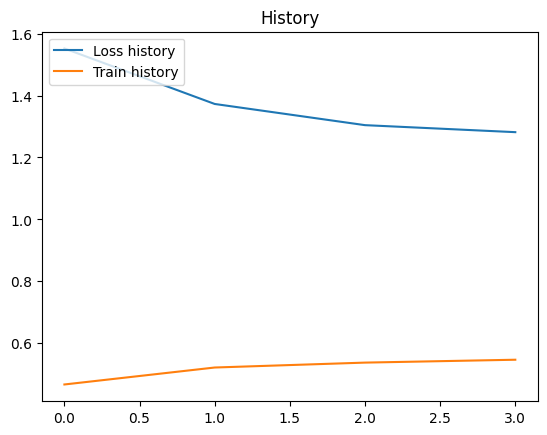

In [ ]:
plt.title("History")
plt.plot(loss_history, label="Loss history")
plt.plot(train_history, label="Train history")
plt.legend(loc="upper left")
plt.show()

In [ ]:
test_loader = DataLoader(test_dataset, batch_size=batch_size)



In [ ]:
accuracy, f1 = evaluate_model(model, test_loader)
print(f"Test accuracy is {accuracy}")
print(f"Test f1 score is {f1}")


Test accuracy is 0.5805759803921569
Test f1 score is 0.3594956211991656


In [ ]:
torch.save(model, 'st_rubert-nkz-classifier.pth')

In [ ]:
from transformers import AutoTokenizer
import torch


# Prepare your text
text = "охранник"

# Tokenize
encoded = tokenizer(
    text,
    truncation=True,
    padding='max_length',
    max_length=512,  # Use the same max_length as during training
    return_tensors='pt'  # Return PyTorch tensors
)

# Now your input_data consists of:
input_ids = encoded['input_ids']
attention_mask = encoded['attention_mask']

# Load and use model
model = torch.load('st_rubert-nkz-classifier.pth')
model.eval()

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

# Get predictions
predictions = torch.softmax(outputs.logits, dim=1)
predicted_class = torch.argmax(predictions, dim=1)

/var/folders/q4/qhhxpt_d3pzbqqvftwz85mk00000gn/T/ipykernel_12862/4098779609.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('st_rubert-nkz-classifier

In [ ]:


# Define your class labels (replace with your actual labels)
labels = ['2', '2', '2']  # Add your actual class names

# Prepare your text
texts = ["спортивный журналист", "артист дубляжа", "дублер"]  # Your input texts

# Tokenize
encoded = tokenizer(
    texts,
    truncation=True,
    padding='max_length',
    max_length=512,
    return_tensors='pt'
)

# Get predictions
with torch.no_grad():
    outputs = model(
        input_ids=encoded['input_ids'],
        attention_mask=encoded['attention_mask']
    )

# Get probabilities and predictions
probabilities = torch.softmax(outputs.logits, dim=1)
predicted_classes = torch.argmax(probabilities, dim=1)

# Print results
print("\nPrediction Results:")
print("-" * 50)
for idx, text in enumerate(texts):
    pred_class = predicted_classes[idx].item()
    probs = probabilities[idx]

    print(f"\nText: {text}")
    print(f"Predicted class: {pred_class}")


RuntimeError: Placeholder storage has not been allocated on MPS device!

In [ ]:
df_filtered = df_transformed[df_transformed['target'].isin([3799, 5029, 697])]
df_filtered


,code,job_title,target
2531,1323-0-028,управляющий строительным участком,697
2532,1323-0-028,руководитель строительного участка,697
2533,1323-0-028,прораб,697
2534,1323-0-028,начальник строительства,697
14217,2642-1-018,обозреватель спортивный,3799
14218,2642-1-018,спортивный обозреватель,3799
14219,2642-1-018,спортивный комментатор,3799
14220,2642-1-018,журналист спортивных новостей,3799
14221,2642-1-018,аналитик спортивных событий,3799
19420,3439-0-002,артист миманса,5029
